In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("vgsales.csv")
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [2]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])
print("Названия столбцов:", df.columns.tolist())
print("\nТипы данных:")
print(df.dtypes)
print("\nОсновные статистические характеристики:")
display(df.describe())
print("\nЧисловые столбцы:")
print(df.select_dtypes(include=np.number).columns.tolist())
print("\nТекстовые столбцы:")
print(df.select_dtypes(include="object").columns.tolist())
print("\nСтолбцы с продажами:")
print(["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"])

Количество строк: 16598
Количество столбцов: 11
Названия столбцов: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Типы данных:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Основные статистические характеристики:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000



Числовые столбцы:
['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Текстовые столбцы:
['Name', 'Platform', 'Genre', 'Publisher']

Столбцы с продажами:
['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [3]:
missing = df.isnull().sum()
print(missing)
print("\nСтолбцы с пропусками:")
print(missing[missing > 0])
print("\nСтроки, в которых отсутствует Year:")
display(df[df["Year"].isnull()])

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Столбцы с пропусками:
Year         271
Publisher     58
dtype: int64

Строки, в которых отсутствует Year:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [4]:
df_clean = df.dropna(subset=["Year"])
print("Размер исходного набора:", df.shape)
print("Размер очищенного набора:", df_clean.shape)
print("Удалено строк:", len(df) - len(df_clean))
print("\nПропуски в очищенном наборе:")
print(df_clean.isnull().sum())

Размер исходного набора: (16598, 11)
Размер очищенного набора: (16327, 11)
Удалено строк: 271

Пропуски в очищенном наборе:
Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64


In [5]:
print("Жанры:")
print(df_clean["Genre"].unique())
print("Количество жанров:", df_clean["Genre"].nunique())
print("\nПлатформы:")
print(df_clean["Platform"].unique())
print("Количество платформ:", df_clean["Platform"].nunique())
print("\nКоличество издателей:", df_clean["Publisher"].nunique())

Жанры:
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
Количество жанров: 12

Платформы:
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Количество платформ: 31

Количество издателей: 576


In [6]:
genre_count = df_clean.groupby("Genre")["Name"].count().sort_values(ascending=False)
genre_count

Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64

In [7]:
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
genre_sales

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64

In [8]:
top_games = df_clean.nlargest(10, "Global_Sales")[["Rank", "Name", "Platform", "Genre", "Global_Sales"]]
top_games

,Rank,Name,Platform,Genre,Global_Sales
0,1,Wii Sports,Wii,Sports,82.74
1,2,Super Mario Bros.,NES,Platform,40.24
2,3,Mario Kart Wii,Wii,Racing,35.82
3,4,Wii Sports Resort,Wii,Sports,33.00
4,5,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,6,Tetris,GB,Puzzle,30.26
6,7,New Super Mario Bros.,DS,Platform,30.01
7,8,Wii Play,Wii,Misc,29.02
8,9,New Super Mario Bros. Wii,Wii,Platform,28.62
9,10,Duck Hunt,NES,Shooter,28.31


In [9]:
platform_count = df_clean.groupby("Platform")["Name"].count().sort_values(ascending=False)
print("10 платформ с наибольшим количеством игр:")
display(platform_count.head(10))
platform_sales = df_clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
print("10 платформ с наибольшими суммарными продажами:")
display(platform_sales.head(10))

10 платформ с наибольшим количеством игр:


Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: Name, dtype: int64

10 платформ с наибольшими суммарными продажами:


Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64

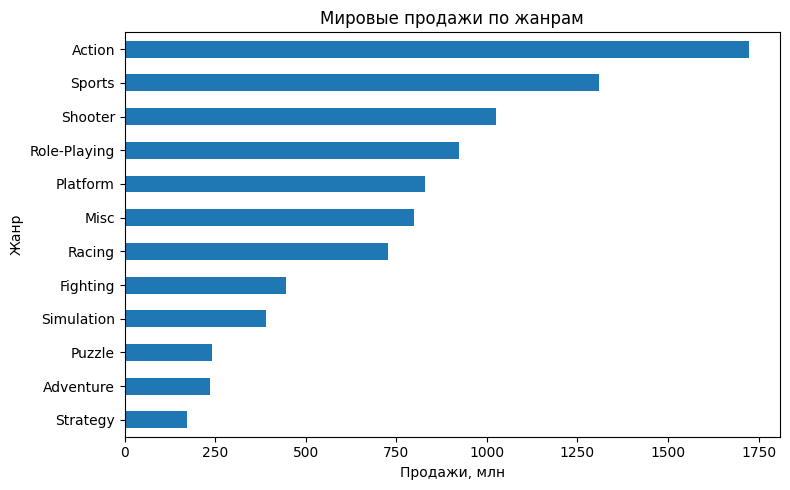

Наибольшие продажи: {'Action': 1722.88, 'Sports': 1309.24, 'Shooter': 1026.2}
Наименьшие продажи: {'Puzzle': 242.22, 'Adventure': 234.8, 'Strategy': 173.43}


In [10]:
plt.figure(figsize=(8, 5))
genre_sales.sort_values().plot(kind="barh")
plt.title("Мировые продажи по жанрам")
plt.xlabel("Продажи, млн")
plt.ylabel("Жанр")
plt.tight_layout()
plt.show()
print("Наибольшие продажи:", genre_sales.head(3).to_dict())
print("Наименьшие продажи:", genre_sales.tail(3).to_dict())

In [11]:
corr_na_global = df_clean[["NA_Sales", "Global_Sales"]].corr()
corr_value = corr_na_global.loc["NA_Sales", "Global_Sales"]
print(corr_na_global)
print("\nКоэффициент корреляции:", round(corr_value, 4))

              NA_Sales  Global_Sales
NA_Sales      1.000000      0.941268
Global_Sales  0.941268      1.000000

Коэффициент корреляции: 0.9413


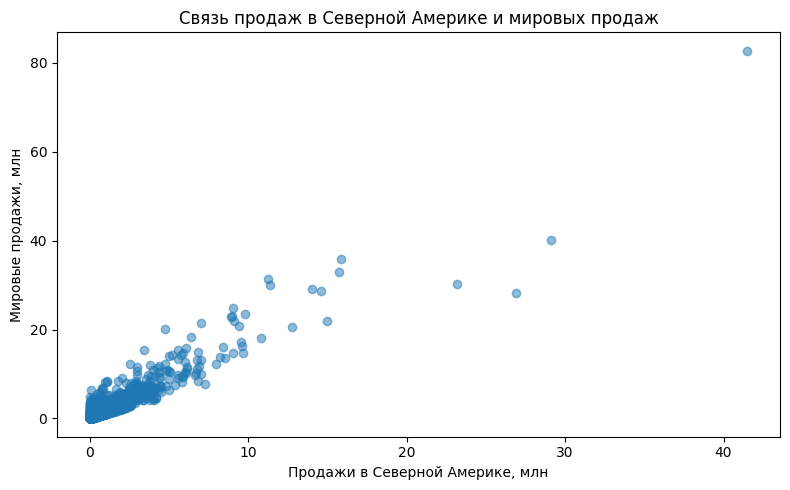

Одна точка соответствует одной игре.
Наблюдается восходящая тенденция, что соответствует положительной корреляции.


In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["NA_Sales"], df_clean["Global_Sales"], alpha=0.5)
plt.title("Связь продаж в Северной Америке и мировых продаж")
plt.xlabel("Продажи в Северной Америке, млн")
plt.ylabel("Мировые продажи, млн")
plt.tight_layout()
plt.show()
print("Одна точка соответствует одной игре.")
print("Наблюдается восходящая тенденция, что соответствует положительной корреляции.")

In [13]:
regional_corr = df_clean[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].corr()
print(regional_corr)
pairs=[]
cols=regional_corr.columns
for i in range(len(cols)):
    for j in range(i+1,len(cols)):
        pairs.append((cols[i],cols[j],regional_corr.iloc[i,j]))
pairs.sort(key=lambda x:x[2], reverse=True)
print("\nСамая сильная связь между регионами:", pairs[0])
print("\nВывод: после очистки анализ выполнялся на df_clean. Продажи в Северной Америке имеют выраженную положительную связь с мировыми продажами. Среди региональных продаж сильнее всего связаны NA_Sales и EU_Sales.")

             NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales     1.000000  0.768936  0.451285     0.634508
EU_Sales     0.768936  1.000000  0.436414     0.726266
JP_Sales     0.451285  0.436414  1.000000     0.290653
Other_Sales  0.634508  0.726266  0.290653     1.000000

Самая сильная связь между регионами: ('NA_Sales', 'EU_Sales', np.float64(0.7689362623668553))

Вывод: после очистки анализ выполнялся на df_clean. Продажи в Северной Америке имеют выраженную положительную связь с мировыми продажами. Среди региональных продаж сильнее всего связаны NA_Sales и EU_Sales.
